# Facility lifecycle: commissioning, start-up, shutdown, late life, and decommissioning

This notebook fills the operational bookends around steady production. It connects commissioning
fluids and drying, production start-up, controlled shutdown and inventory reduction, late-life
economic limits, cessation planning, well plug-and-abandonment, removal, waste, cost, and emissions.

NeqSim Java `master` supplies real-fluid properties, phase separation, compression demand, and gas
inventory. Python supplies sequences, operating envelopes, schedules, uncertainty, and decision
analysis. All data are synthetic screening assumptions, not operating procedures or regulatory
submissions.


In [1]:
import importlib.util
import os
from pathlib import Path
import subprocess
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-complete-value-chain-matplotlib")
SUPPORT_PACKAGES = {
    "jpype": "jpype1",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
}
missing = [
    package
    for module, package in SUPPORT_PACKAGES.items()
    if importlib.util.find_spec(module) is None
]
if missing:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "--no-cache-dir", *missing],
        check=True,
        timeout=900,
    )
print("Python dependency gate passed.")


Python dependency gate passed.


In [2]:
from importlib.metadata import version
import hashlib
import os
import platform
from pathlib import Path
import subprocess

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
    }
)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4g}")

package_versions = pd.DataFrame(
    {
        "package": ["Python", "JPype", "NumPy", "Pandas", "SciPy", "Matplotlib"],
        "version": [
            platform.python_version(),
            version("jpype1"),
            version("numpy"),
            version("pandas"),
            version("scipy"),
            version("matplotlib"),
        ],
    }
)
display(package_versions)


,package,version
0,Python,3.12.13
1,JPype,1.7.1
2,NumPy,2.5.1
3,Pandas,3.0.5
4,SciPy,1.18.0
5,Matplotlib,3.11.1


## Reproducible NeqSim Java `master`

The bootstrap builds the current NeqSim Java master in Colab and records the exact source commit and
JAR hash. Local validation may inject an equivalent source build.


In [3]:
def run_command(command, *, cwd=None, timeout=1200):
    result = subprocess.run(
        command,
        cwd=cwd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
    )
    if result.returncode != 0:
        tail = "\n".join(result.stdout.splitlines()[-80:])
        raise RuntimeError(
            f"Command failed ({result.returncode}): {command}\n{tail}"
        )
    return result.stdout.strip()


NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
supplied_source = os.environ.get("NEQSIM_SOURCE_ROOT", "").strip()
supplied_jar = os.environ.get("NEQSIM_SOURCE_JAR", "").strip()

if supplied_source and supplied_jar:
    neqsim_source = Path(supplied_source).resolve()
    neqsim_jar = Path(supplied_jar).resolve()
else:
    build_root = Path("/content") if Path("/content").exists() else Path.cwd()
    neqsim_source = build_root / "neqsim-java-master"
    if not neqsim_source.exists():
        run_command(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                "https://github.com/equinor/neqsim.git",
                str(neqsim_source),
            ],
            timeout=600,
        )
    else:
        run_command(
            ["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
            cwd=neqsim_source,
            timeout=600,
        )
        run_command(
            ["git", "checkout", "--detach", "FETCH_HEAD"],
            cwd=neqsim_source,
        )
    run_command(
        ["./mvnw", "-q", "-DskipTests", "-Dmaven.javadoc.skip=true", "package"],
        cwd=neqsim_source,
        timeout=1500,
    )
    built_jars = sorted(
        path
        for path in (neqsim_source / "target").glob("neqsim-*.jar")
        if "sources" not in path.name
        and "javadoc" not in path.name
        and not path.name.startswith("original-")
    )
    if not built_jars:
        raise FileNotFoundError("Maven completed but no NeqSim JAR was found.")
    neqsim_jar = built_jars[-1]

if not neqsim_source.is_dir() or not neqsim_jar.is_file():
    raise FileNotFoundError("NeqSim source root or built JAR is missing.")

neqsim_commit = run_command(["git", "rev-parse", "HEAD"], cwd=neqsim_source)
neqsim_jar_sha256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()

os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
if not jpype.isJVMStarted():
    jpype.addClassPath(str(neqsim_jar))
    local_m2 = os.environ.get("NEQSIM_VALIDATION_M2", "").strip()
    if local_m2:
        for dependency in sorted(Path(local_m2).rglob("*.jar")):
            if dependency.resolve() != neqsim_jar:
                jpype.addClassPath(str(dependency))
    jpype.startJVM()

JClass = jpype.JClass
MainOnlyClass = JClass("neqsim.thermo.system.SystemSrkEos")
class_source = str(
    MainOnlyClass.class_.getProtectionDomain().getCodeSource().getLocation()
)
if neqsim_jar.name not in class_source:
    raise RuntimeError("NeqSim classes were not loaded from the source-built JAR.")

provenance_table = pd.DataFrame(
    {
        "item": [
            "NeqSim source ref",
            "NeqSim commit",
            "JAR SHA-256",
            "Java class source",
        ],
        "resolved value": [
            NEQSIM_SOURCE_REF,
            neqsim_commit,
            neqsim_jar_sha256,
            class_source,
        ],
    }
)
display(provenance_table)


,item,resolved value
0,NeqSim source ref,master
1,NeqSim commit,0c9a5426247ffa34191b9dc5ed6ea9e89937da18
2,JAR SHA-256,7bad6b03b40dee23aa7a795c5ad1fa09802f567fab2bff...
3,Java class source,file:/tmp/neqsim-0c9a542-compiled.jar


## 1. A lifecycle basis prevents unsafe handoff gaps

Commissioning and decommissioning use many of the same system boundaries in reverse. Both require a
known inventory, pressure/temperature limits, fluid compatibility, isolation status, emissions
boundary, acceptance criteria, and accountable handover.


In [4]:
lifecycle_stages = pd.DataFrame(
    {
        "stage": [
            "Mechanical completion",
            "Leak test and drying",
            "Hydrocarbon introduction",
            "Ramp-up and operation",
            "Shutdown and preservation",
            "Late-life optimization",
            "Cessation and isolation",
            "P&A, removal, and monitoring",
        ],
        "acceptance evidence": [
            "system completion and punch status",
            "test boundary, dew point, leak rate",
            "composition, inventory, ignition controls",
            "stable levels, pressures, compressor margin",
            "isolated energy and preserved equipment",
            "safe margin, availability, positive value",
            "hydrocarbon-free and barrier verification",
            "well barriers, waste route, site survey",
        ],
        "NeqSim contribution": [
            "fluid compatibility properties",
            "nitrogen density and inventory",
            "phase behavior and linepack",
            "separation and compression",
            "depressurization and remaining inventory",
            "process loads, power, water, emissions",
            "flush and residual-fluid basis",
            "thermodynamic inventory handoff",
        ],
    }
)
display(lifecycle_stages)


,stage,acceptance evidence,NeqSim contribution
0,Mechanical completion,system completion and punch status,fluid compatibility properties
1,Leak test and drying,"test boundary, dew point, leak rate",nitrogen density and inventory
2,Hydrocarbon introduction,"composition, inventory, ignition controls",phase behavior and linepack
3,Ramp-up and operation,"stable levels, pressures, compressor margin",separation and compression
4,Shutdown and preservation,isolated energy and preserved equipment,depressurization and remaining inventory
5,Late-life optimization,"safe margin, availability, positive value","process loads, power, water, emissions"
6,Cessation and isolation,hydrocarbon-free and barrier verification,flush and residual-fluid basis
7,"P&A, removal, and monitoring","well barriers, waste route, site survey",thermodynamic inventory handoff


## 2. Commissioning fluids: nitrogen is not a hydrocarbon surrogate

Linepack, test load, purge demand, stored energy, cooling, and detector response depend on real-fluid
properties. At fixed volume $V$, the inventory is

$$m=\rho(P,T,\mathbf{z})V$$

The comparison below uses NeqSim SRK properties for nitrogen and a methane-rich process gas at the
same pressure and temperature.


,fluid,density kg/m³,Z,Cp J/(kg K),Cv J/(kg K),Cp/Cv,pressure bara,inventory t
0,nitrogen,11.51,0.999,"1,058",745.7,1.418,10,13.81
1,nitrogen,57.48,1.002,"1,134",762.8,1.486,50,68.98
2,nitrogen,113.6,1.015,"1,218",782.7,1.556,100,136.3
3,process gas,7.51,0.976,"2,190","1,663",1.317,10,9.012
4,process gas,41.42,0.887,"2,569","1,707",1.505,50,49.71
5,process gas,91.96,0.801,"3,204","1,767",1.813,100,110.4


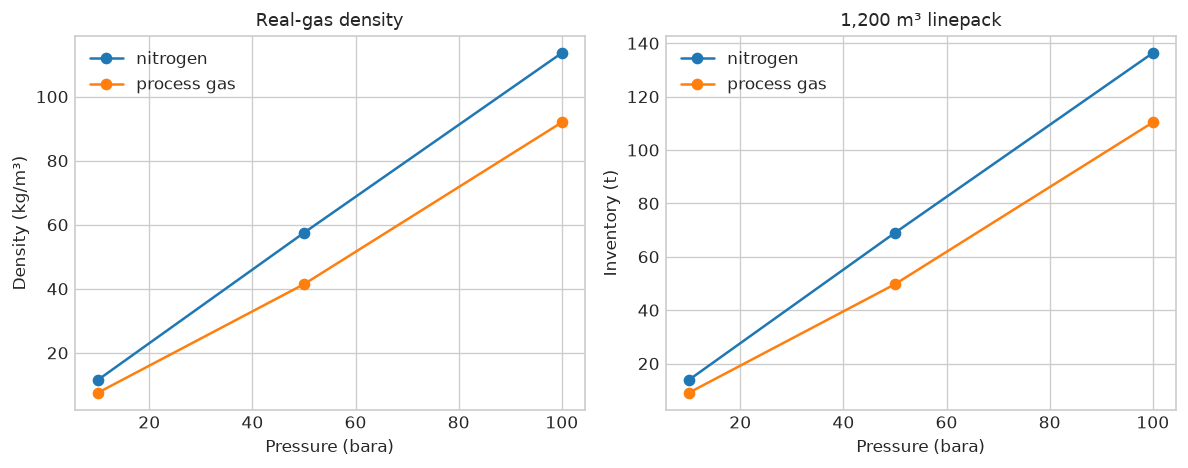

In [5]:
SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
ThermodynamicOperations = JClass(
    "neqsim.thermodynamicoperations.ThermodynamicOperations"
)


def gas_properties(name, composition, temperature_c, pressure_bara):
    fluid = SystemSrkEos(273.15 + temperature_c, pressure_bara)
    for component, amount in composition.items():
        fluid.addComponent(component, amount)
    fluid.setMixingRule("classic")
    ThermodynamicOperations(fluid).TPflash()
    fluid.initProperties()
    return {
        "fluid": name,
        "density kg/m³": float(fluid.getDensity("kg/m3")),
        "Z": float(fluid.getZ()),
        "Cp J/(kg K)": float(fluid.getCp("J/kgK")),
        "Cv J/(kg K)": float(fluid.getCv("J/kgK")),
        "Cp/Cv": float(fluid.getGamma()),
    }


commissioning_cases = [
    ("nitrogen", {"nitrogen": 1.0}),
    ("process gas", {"methane": 0.90, "ethane": 0.07, "propane": 0.03}),
]
property_rows = [
    gas_properties(name, composition, 20.0, pressure)
    for name, composition in commissioning_cases
    for pressure in [10.0, 50.0, 100.0]
]
properties = pd.DataFrame(property_rows)
properties["pressure bara"] = np.tile([10.0, 50.0, 100.0], 2)

pipeline_volume_m3 = 1_200.0
properties["inventory t"] = (
    properties["density kg/m³"] * pipeline_volume_m3 / 1_000.0
)
display(properties.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.0))
for fluid_name, group in properties.groupby("fluid"):
    axes[0].plot(
        group["pressure bara"],
        group["density kg/m³"],
        "o-",
        label=fluid_name,
    )
    axes[1].plot(
        group["pressure bara"],
        group["inventory t"],
        "o-",
        label=fluid_name,
    )
axes[0].set(xlabel="Pressure (bara)", ylabel="Density (kg/m³)", title="Real-gas density")
axes[1].set(xlabel="Pressure (bara)", ylabel="Inventory (t)", title="1,200 m³ linepack")
for axis in axes:
    axis.legend()
plt.tight_layout()
plt.show()


## 3. Drying and inerting are measurable material balances

For an ideal well-mixed purge, the remaining contaminant fraction after $N$ volume changes is
$C/C_0=\exp(-N)$. Real systems can short-circuit and contain dead legs, so a mixing-efficiency factor
and measured outlet dew point are required. The calculation sizes a screening nitrogen demand; the
acceptance criterion remains an instrumented system test.


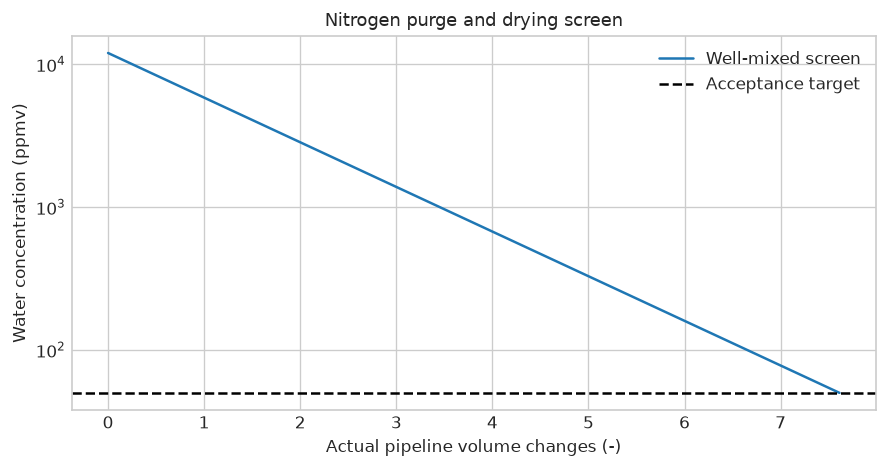

,metric,value,unit
0,Required volume changes,7.61,-
1,Nitrogen volume,"9,134",actual m³ at 10 bara
2,Nitrogen mass at 10 bara,105.1,t
3,Nominal purge duration,2.28,h


In [6]:
initial_water_ppmv = 12_000.0
target_water_ppmv = 50.0
mixing_efficiency = 0.72
required_ideal_changes = np.log(initial_water_ppmv / target_water_ppmv)
required_actual_changes = required_ideal_changes / mixing_efficiency
nitrogen_actual_m3 = required_actual_changes * pipeline_volume_m3

nitrogen_at_10_bara = properties.query(
    "fluid == 'nitrogen' and `pressure bara` == 10.0"
).iloc[0]
nitrogen_mass_t = (
    nitrogen_at_10_bara["density kg/m³"]
    * nitrogen_actual_m3
    / 1_000.0
)
purge_rate_actual_m3_h = 4_000.0
purge_duration_h = nitrogen_actual_m3 / purge_rate_actual_m3_h

purge_changes = np.linspace(0.0, required_actual_changes, 80)
water_ppmv = initial_water_ppmv * np.exp(-mixing_efficiency * purge_changes)

fig, axis = plt.subplots(figsize=(7.5, 4.0))
axis.semilogy(purge_changes, water_ppmv, label="Well-mixed screen")
axis.axhline(target_water_ppmv, color="black", linestyle="--", label="Acceptance target")
axis.set(
    xlabel="Actual pipeline volume changes (-)",
    ylabel="Water concentration (ppmv)",
    title="Nitrogen purge and drying screen",
)
axis.legend()
plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {
            "metric": [
                "Required volume changes",
                "Nitrogen volume",
                "Nitrogen mass at 10 bara",
                "Nominal purge duration",
            ],
            "value": [
                required_actual_changes,
                nitrogen_actual_m3,
                nitrogen_mass_t,
                purge_duration_h,
            ],
            "unit": ["-", "actual m³ at 10 bara", "t", "h"],
        }
    ).round(2)
)


## 4. Start-up: ramp the process within both process and machinery envelopes

A successful hydrocarbon introduction is not just a flow ramp. Separator stability, compressor
minimum flow, pressure, temperature, liquid arrival, recycle, utilities, flare capacity, and product
specification must be sequenced. This compact screen uses NeqSim at every ramp point and overlays a
minimum stable compressor-flow criterion.


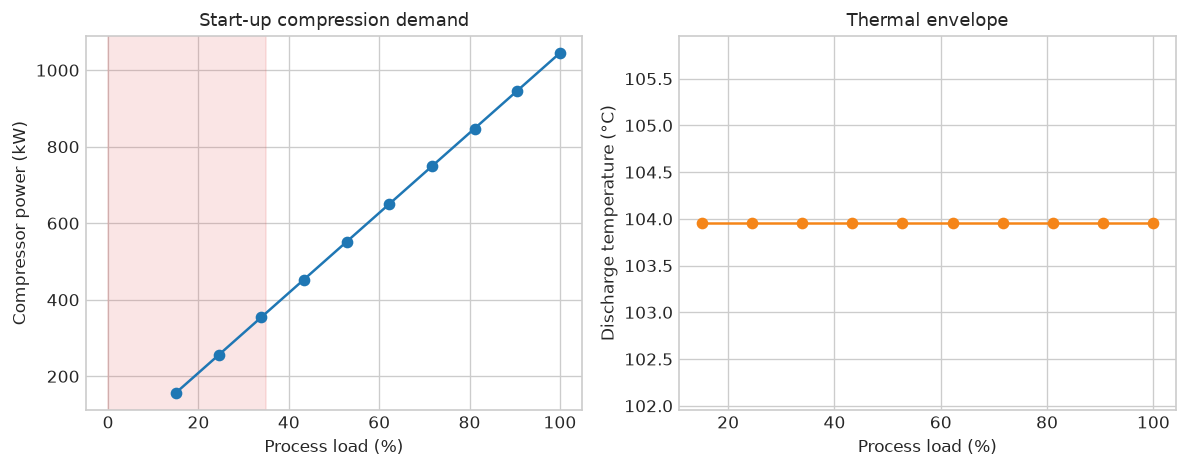

,load fraction,feed kg/h,gas kg/h,liquid kg/h,compressor kW,discharge °C,mass residual,native stable without recycle,recycle required,accepted load
0,0.15,"4,500","4,117",383.1,156.7,104,0,False,True,0.35
1,0.24,"7,333","6,709",624.2,255.4,104,0,False,True,0.35
2,0.34,1.017e+04,"9,301",865.4,354.1,104,0,False,True,0.35
3,0.43,1.3e+04,1.189e+04,"1,107",452.8,104,0,True,False,0.43
4,0.53,1.583e+04,1.449e+04,"1,348",551.5,104,0,True,False,0.53
5,0.62,1.867e+04,1.708e+04,"1,589",650.2,104,0,True,False,0.62
6,0.72,2.15e+04,1.967e+04,"1,830",748.9,104,0,True,False,0.72
7,0.81,2.433e+04,2.226e+04,"2,071",847.5,104,0,True,False,0.81
8,0.91,2.717e+04,2.485e+04,"2,313",946.2,104,0,True,False,0.91
9,1,3e+04,2.745e+04,"2,554","1,045",104,0,True,False,1


In [7]:
Stream = JClass("neqsim.process.equipment.stream.Stream")
Separator = JClass("neqsim.process.equipment.separator.Separator")
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")


def run_startup_case(load_fraction):
    startup_fluid = SystemSrkEos(273.15 + 35.0, 52.0)
    startup_composition = {
        "methane": 0.88,
        "ethane": 0.07,
        "propane": 0.03,
        "n-heptane": 0.02,
    }
    for component, amount in startup_composition.items():
        startup_fluid.addComponent(component, amount)
    startup_fluid.setMixingRule("classic")
    startup_fluid.setMultiPhaseCheck(True)

    feed = Stream(f"Start-up feed {load_fraction:.2f}", startup_fluid)
    feed.setFlowRate(30_000.0 * load_fraction, "kg/hr")
    feed.run()
    separator = Separator(f"Inlet separator {load_fraction:.2f}", feed)
    separator.run()

    compressor = Compressor(
        f"Export compressor {load_fraction:.2f}",
        separator.getGasOutStream(),
    )
    compressor.setOutletPressure(110.0)
    compressor.setIsentropicEfficiency(0.76)
    compressor.run()
    gas_rate = float(separator.getGasOutStream().getFlowRate("kg/hr"))
    liquid_rate = float(separator.getLiquidOutStream().getFlowRate("kg/hr"))
    feed_rate = float(feed.getFlowRate("kg/hr"))
    relative_mass_residual = abs(gas_rate + liquid_rate - feed_rate) / feed_rate
    return {
        "load fraction": load_fraction,
        "feed kg/h": feed_rate,
        "gas kg/h": gas_rate,
        "liquid kg/h": liquid_rate,
        "compressor kW": float(compressor.getPower("kW")),
        "discharge °C": float(compressor.getOutletStream().getTemperature("C")),
        "mass residual": relative_mass_residual,
    }


startup = pd.DataFrame(
    [run_startup_case(load) for load in np.linspace(0.15, 1.0, 10)]
)
minimum_stable_load = 0.35
startup["native stable without recycle"] = (
    startup["load fraction"] >= minimum_stable_load
)
startup["recycle required"] = ~startup["native stable without recycle"]
startup["accepted load"] = np.maximum(
    startup["load fraction"],
    minimum_stable_load,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.0))
axes[0].plot(
    100.0 * startup["load fraction"],
    startup["compressor kW"],
    "o-",
)
axes[0].axvspan(0.0, 100.0 * minimum_stable_load, color="#e45756", alpha=0.15)
axes[0].set(
    xlabel="Process load (%)",
    ylabel="Compressor power (kW)",
    title="Start-up compression demand",
)
axes[1].plot(
    100.0 * startup["load fraction"],
    startup["discharge °C"],
    "o-",
    color="#f58518",
)
axes[1].set(
    xlabel="Process load (%)",
    ylabel="Discharge temperature (°C)",
    title="Thermal envelope",
)
temperature_center = startup["discharge °C"].mean()
axes[1].set_ylim(temperature_center - 2.0, temperature_center + 2.0)
axes[1].ticklabel_format(axis="y", style="plain", useOffset=False)
plt.tight_layout()
plt.show()
display(startup.round(2))


## 5. Shutdown: pressure is not the same as remaining hydrocarbon mass

For a fixed gas volume, each pressure step is flashed with NeqSim at the initial temperature to
create a monotonic isothermal inventory reference. A separate adiabatic temperature curve screens
the possible low-temperature direction. The released reference inventory between steps is

$$\Delta m_i=m(P_i,T_i)-m(P_{i+1},T_{i+1})$$

The adiabatic curve is bounded at $-60\ ^\circ\mathrm{C}$ as an explicit screening floor; it is not
a predicted final temperature. This is not a relief or blowdown design. A final design needs a
coupled mass-and-energy transient, wall heat capacity, valve/flare hydraulics, low-temperature
limits, hydrate/condensation checks, and disposal capacity.


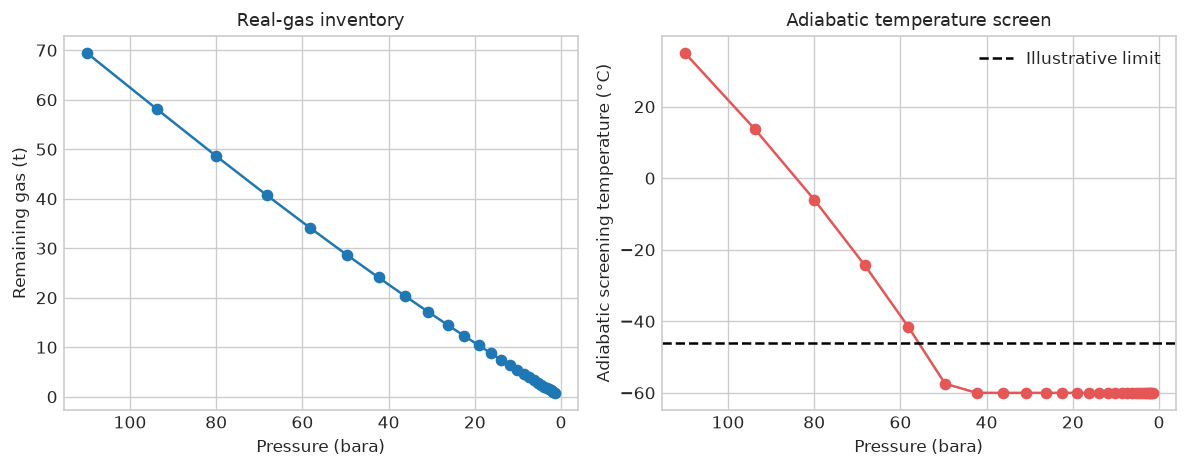

,pressure bara,adiabatic screen °C,density kg/m³,inventory t,released t,cumulative released t
0,110,35,92.59,69.45,-0,0
7,36.12,-60,27.07,20.3,3.789,49.14
14,11.86,-60,8.472,6.354,1.126,63.09
21,3.896,-60,2.738,2.054,0.357,67.39
27,1.5,-60,1.049,0.787,0.136,68.66


In [8]:
gas_volume_m3 = 750.0
initial_pressure_bara = 110.0
initial_temperature_k = 273.15 + 35.0
gamma_screen = float(
    properties.query(
        "fluid == 'process gas' and `pressure bara` == 100.0"
    )["Cp/Cv"].iloc[0]
)
pressure_profile_bara = np.geomspace(initial_pressure_bara, 1.5, 28)

shutdown_rows = []
for pressure_bara in pressure_profile_bara:
    adiabatic_temperature_k = initial_temperature_k * (
        pressure_bara / initial_pressure_bara
    ) ** ((gamma_screen - 1.0) / gamma_screen)
    adiabatic_temperature_k = max(adiabatic_temperature_k, 213.15)
    state = gas_properties(
        "process gas",
        {"methane": 0.90, "ethane": 0.07, "propane": 0.03},
        initial_temperature_k - 273.15,
        float(pressure_bara),
    )
    shutdown_rows.append(
        {
            "pressure bara": pressure_bara,
            "adiabatic screen °C": adiabatic_temperature_k - 273.15,
            "density kg/m³": state["density kg/m³"],
            "inventory t": state["density kg/m³"] * gas_volume_m3 / 1_000.0,
        }
    )

shutdown = pd.DataFrame(shutdown_rows)
shutdown["released t"] = -shutdown["inventory t"].diff().fillna(0.0)
shutdown["cumulative released t"] = (
    shutdown["inventory t"].iloc[0] - shutdown["inventory t"]
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.0))
axes[0].plot(shutdown["pressure bara"], shutdown["inventory t"], "o-")
axes[0].set(
    xlabel="Pressure (bara)",
    ylabel="Remaining gas (t)",
    title="Real-gas inventory",
)
axes[1].plot(
    shutdown["pressure bara"],
    shutdown["adiabatic screen °C"],
    "o-",
    color="#e45756",
)
axes[1].axhline(-46.0, color="black", linestyle="--", label="Illustrative limit")
axes[1].set(
    xlabel="Pressure (bara)",
    ylabel="Adiabatic screening temperature (°C)",
    title="Adiabatic temperature screen",
)
axes[1].legend()
for axis in axes:
    axis.invert_xaxis()
plt.tight_layout()
plt.show()
display(shutdown.iloc[[0, 7, 14, 21, -1]].round(3))


## 6. Late life: the economic limit is constrained by safe operability

Positive operating cash flow is necessary but not sufficient. A field must also retain well
integrity, minimum stable flow, water-handling capacity, export specification, maintenance support,
and regulatory consent. The screening cash flow is

$$CF_t=R_t-OPEX_t-C_{integrity,t}-C_{carbon,t}$$

The economic-limit candidate is the first year with non-positive cash flow after production has
started. The decision remains scenario- and obligation-dependent.


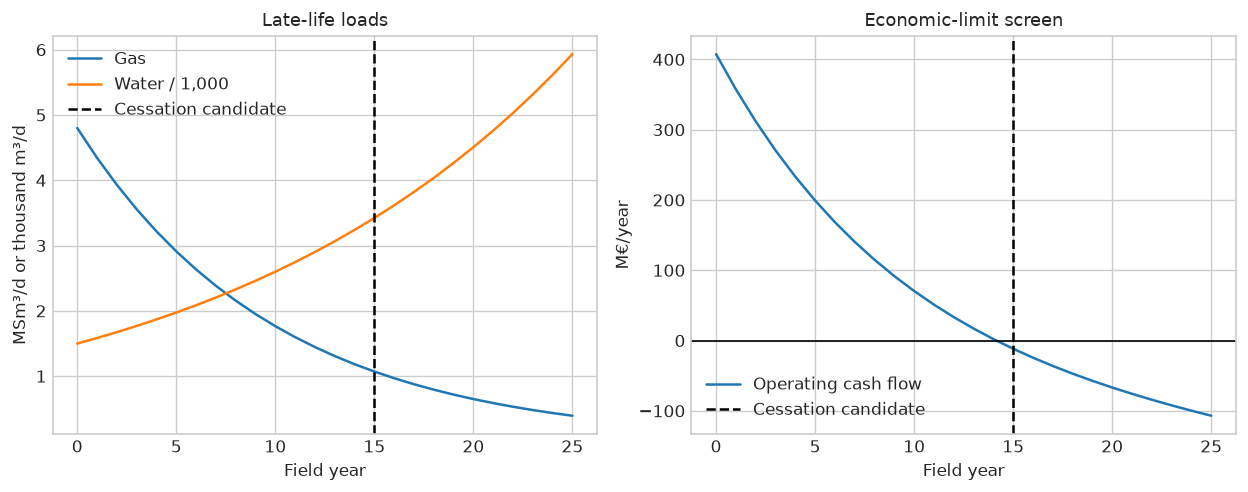

,year,gas MSm³/d,water m³/d,availability,revenue M€/y,OPEX M€/y,carbon cost M€/y,cash M€/y,emissions kt/y
0,0,4.8,"1,500",0.96,507.2,99.46,0.17,407.6,1.74
5,5,2.91,"1,975",0.95,302.1,102.7,0.1,199.2,1.05
10,10,1.77,"2,600",0.93,179.8,109.3,0.06,70.47,0.64
15,15,1.07,"3,423",0.91,107,118.6,0.04,-11.62,0.39
20,20,0.65,"4,506",0.9,63.66,130.5,0.02,-66.81,0.24
25,25,0.39,"5,933",0.88,37.86,144.8,0.01,-107,0.14


In [9]:
late_year = np.arange(0, 26)
gas_rate_msm3_d = 4.8 * np.exp(-0.10 * late_year)
water_rate_m3_d = 1_500.0 * np.exp(0.055 * late_year)
availability = np.clip(0.965 - 0.0035 * late_year, 0.84, 1.0)
saleable_gas_msm3_d = gas_rate_msm3_d * availability

gas_price_eur_sm3 = 0.30
annual_revenue_meur = saleable_gas_msm3_d * 1.0e6 * 365.0 * gas_price_eur_sm3 / 1.0e6
base_opex_meur = 92.0
water_opex_meur = water_rate_m3_d * 365.0 * 4.5 / 1.0e6
integrity_opex_meur = 5.0 + 0.16 * late_year ** 1.7
power_mw = startup["compressor kW"].iloc[-1] / 1_000.0 * (
    gas_rate_msm3_d / gas_rate_msm3_d[0]
)
emissions_kt_y = power_mw * 8_760.0 * 0.19 / 1_000.0
carbon_cost_meur = emissions_kt_y * 95.0 / 1_000.0
annual_cash_meur = (
    annual_revenue_meur
    - base_opex_meur
    - water_opex_meur
    - integrity_opex_meur
    - carbon_cost_meur
)

negative_years = late_year[annual_cash_meur <= 0.0]
economic_limit_year = int(negative_years[0]) if len(negative_years) else int(late_year[-1])
minimum_stable_rate = 0.65
below_minimum_years = late_year[gas_rate_msm3_d < minimum_stable_rate]
minimum_flow_year = (
    int(below_minimum_years[0])
    if len(below_minimum_years)
    else int(late_year[-1])
)
cessation_candidate_year = min(economic_limit_year, minimum_flow_year)

late_life = pd.DataFrame(
    {
        "year": late_year,
        "gas MSm³/d": gas_rate_msm3_d,
        "water m³/d": water_rate_m3_d,
        "availability": availability,
        "revenue M€/y": annual_revenue_meur,
        "OPEX M€/y": base_opex_meur + water_opex_meur + integrity_opex_meur,
        "carbon cost M€/y": carbon_cost_meur,
        "cash M€/y": annual_cash_meur,
        "emissions kt/y": emissions_kt_y,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].plot(late_year, gas_rate_msm3_d, label="Gas")
axes[0].plot(late_year, water_rate_m3_d / 1_000.0, label="Water / 1,000")
axes[0].axvline(
    cessation_candidate_year,
    color="black",
    linestyle="--",
    label="Cessation candidate",
)
axes[0].set(
    xlabel="Field year",
    ylabel="MSm³/d or thousand m³/d",
    title="Late-life loads",
)
axes[0].legend()

axes[1].plot(late_year, annual_cash_meur, label="Operating cash flow")
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].axvline(
    cessation_candidate_year,
    color="black",
    linestyle="--",
    label="Cessation candidate",
)
axes[1].set(xlabel="Field year", ylabel="M€/year", title="Economic-limit screen")
axes[1].legend()
plt.tight_layout()
plt.show()
display(late_life.iloc[::5].round(2))


## 7. Decommissioning: plan the obligation before cessation

The work breakdown must connect wells, subsea systems, flowlines, topsides, onshore/export interfaces,
waste routes, monitoring, and retained liabilities. The synthetic schedule below separates cost
uncertainty from thermodynamic inventory. It does not prescribe removal versus leave-in-place.


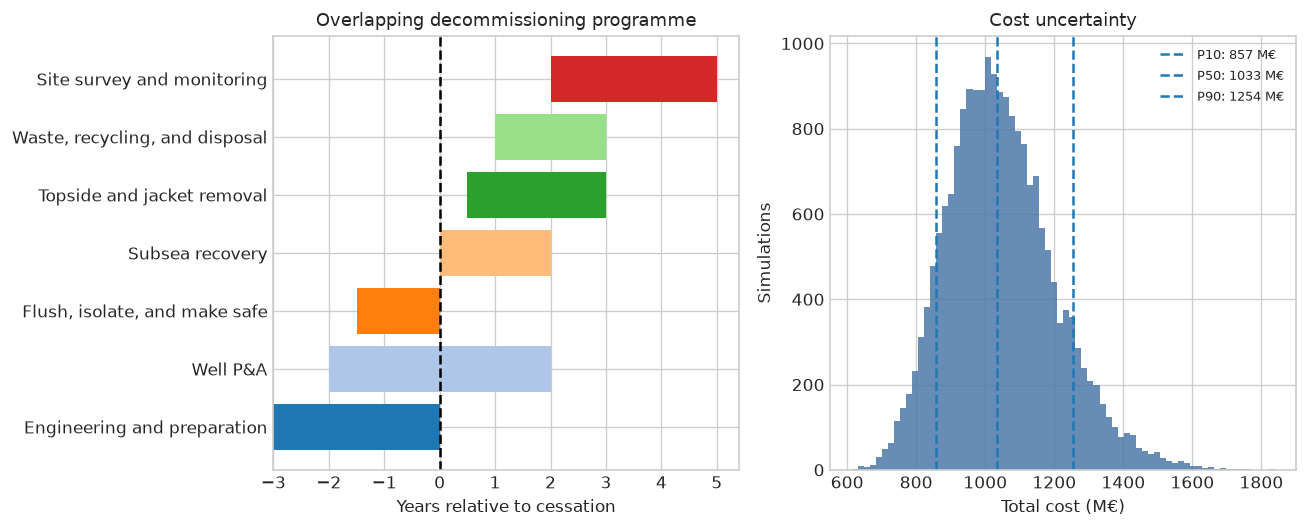

,work package,start year,duration years,base cost M€,recycle fraction
0,Engineering and preparation,-3,3,45,0
1,Well P&A,-2,4,310,0.15
2,"Flush, isolate, and make safe",-1.5,1.5,38,0.35
3,Subsea recovery,0,2,145,0.7
4,Topside and jacket removal,0.5,2.5,420,0.9
5,"Waste, recycling, and disposal",1,2,72,0.75
6,Site survey and monitoring,2,3,18,0


,estimate,total cost M€
0,P10,857.3
1,P50,"1,033"
2,P90,"1,254"


In [10]:
decommission_scope = pd.DataFrame(
    {
        "work package": [
            "Engineering and preparation",
            "Well P&A",
            "Flush, isolate, and make safe",
            "Subsea recovery",
            "Topside and jacket removal",
            "Waste, recycling, and disposal",
            "Site survey and monitoring",
        ],
        "start year": [-3.0, -2.0, -1.5, 0.0, 0.5, 1.0, 2.0],
        "duration years": [3.0, 4.0, 1.5, 2.0, 2.5, 2.0, 3.0],
        "base cost M€": [45.0, 310.0, 38.0, 145.0, 420.0, 72.0, 18.0],
        "recycle fraction": [0.0, 0.15, 0.35, 0.70, 0.90, 0.75, 0.0],
    }
)

rng = np.random.default_rng(20260806)
simulations = 20_000
package_costs = []
for base_cost in decommission_scope["base cost M€"]:
    sigma = 0.28
    mean_shift = np.log(base_cost) - 0.5 * sigma ** 2
    package_costs.append(rng.lognormal(mean_shift, sigma, simulations))
total_decommission_cost = np.vstack(package_costs).sum(axis=0)
cost_quantiles = np.quantile(total_decommission_cost, [0.1, 0.5, 0.9])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for index, row in decommission_scope.iterrows():
    axes[0].barh(
        index,
        row["duration years"],
        left=row["start year"],
        color=plt.cm.tab20(index),
    )
axes[0].set_yticks(
    np.arange(len(decommission_scope)),
    labels=decommission_scope["work package"],
)
axes[0].axvline(0.0, color="black", linestyle="--")
axes[0].set(
    xlabel="Years relative to cessation",
    title="Overlapping decommissioning programme",
)

axes[1].hist(total_decommission_cost, bins=70, color="#4c78a8", alpha=0.85)
for quantile, label in zip(cost_quantiles, ["P10", "P50", "P90"]):
    axes[1].axvline(quantile, linestyle="--", label=f"{label}: {quantile:.0f} M€")
axes[1].set(xlabel="Total cost (M€)", ylabel="Simulations", title="Cost uncertainty")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

display(decommission_scope)
display(
    pd.DataFrame(
        {
            "estimate": ["P10", "P50", "P90"],
            "total cost M€": cost_quantiles,
        }
    ).round(1)
)


## 8. Governed decision gates and notebook handoffs

| Gate | Minimum evidence | Related detailed notebook |
|---|---|---|
| Ready for hydrocarbon introduction | completion, leak/dryness acceptance, inventory, procedures, barriers | process logic and safeguarding |
| Ready for stable operation | separator/control stability, machinery margin, products, emissions | dynamic SURF–topside control |
| Ready for prolonged late life | integrity, reliability, minimum flow, water capacity, positive value | operations and asset management |
| Ready for cessation | obligations, alternatives, schedule, inventory, stakeholder/regulatory basis | decision-gate deliveries |
| Ready for removal/P&A | verified isolation, well barriers, waste route, marine/weather window | metocean and field development |

Relevant NeqSim-Colab notebooks include
[process logic](../process/ProcessLogicIntegrated.ipynb),
[dynamic SURF–topside control](../process/integrated_dynamic_surf_topside_control.ipynb),
[operations and asset management](operations_asset_management_with_neqsim.ipynb),
[produced-water management](../production/produced_water_sand_chemicals_management.ipynb), and
[decision-gate deliveries](../fielddevelopment/discovery_1_dg1_surf_facilities_design.ipynb).


In [11]:
validation = pd.DataFrame(
    {
        "check": [
            "NeqSim source is master",
            "Commissioning properties finite",
            "Start-up simulations finite",
            "Start-up mass closure",
            "Shutdown inventory decreases",
            "Late-life cash flow finite",
            "Decommissioning uncertainty ordered",
        ],
        "passed": [
            NEQSIM_SOURCE_REF == "master",
            np.isfinite(properties.select_dtypes("number").to_numpy()).all(),
            np.isfinite(startup.select_dtypes("number").to_numpy()).all(),
            startup["mass residual"].max() < 1.0e-8,
            shutdown["inventory t"].is_monotonic_decreasing,
            np.isfinite(late_life.select_dtypes("number").to_numpy()).all(),
            bool(cost_quantiles[0] < cost_quantiles[1] < cost_quantiles[2]),
        ],
    }
)
if not validation["passed"].all():
    raise AssertionError(validation.to_string(index=False))
display(validation)

print(
    f"Commissioning purge screen: {required_actual_changes:.1f} volume changes "
    f"and {purge_duration_h:.1f} h at the assumed rate."
)
print(
    f"Cessation candidate: field year {cessation_candidate_year}; "
    f"decommissioning P50 cost: {cost_quantiles[1]:.0f} M€."
)


Commissioning purge screen: 7.6 volume changes and 2.3 h at the assumed rate.
Cessation candidate: field year 15; decommissioning P50 cost: 1033 M€.


,check,passed
0,NeqSim source is master,True
1,Commissioning properties finite,True
2,Start-up simulations finite,True
3,Start-up mass closure,True
4,Shutdown inventory decreases,True
5,Late-life cash flow finite,True
6,Decommissioning uncertainty ordered,True


## Interpretation and limitations

The central recommendation is to model commissioning, operation, cessation, and decommissioning as
one inventory-and-barrier lifecycle. NeqSim makes fluid inventories and process consequences
consistent, while schedule, reliability, cost, waste, and regulatory evidence remain explicit
Python or specialist-tool handoffs.

The purge model assumes well-mixed displacement; the start-up machinery boundary is illustrative;
the shutdown temperature is an adiabatic screen rather than a transient blowdown solution; prices,
OPEX, carbon costs, emissions factors, P&A scope, removal methods, recycling, and cost distributions
are synthetic. Apply governed facility data, native dynamic equipment models, design standards,
permit conditions, and jurisdiction-specific cessation requirements before engineering use.
